Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8252 - loss: 0.4890
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8658 - loss: 0.3652
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8782 - loss: 0.3305
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8865 - loss: 0.3093
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8911 - loss: 0.2926
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8980 - loss: 0.2765
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8996 - loss: 0.2639
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9059 - loss: 0.2535
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9085 - loss: 0.2428
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9085 - loss: 0.2367
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8809 - loss: 0.3435

Precisión en test: 0.8809000253677368
313/

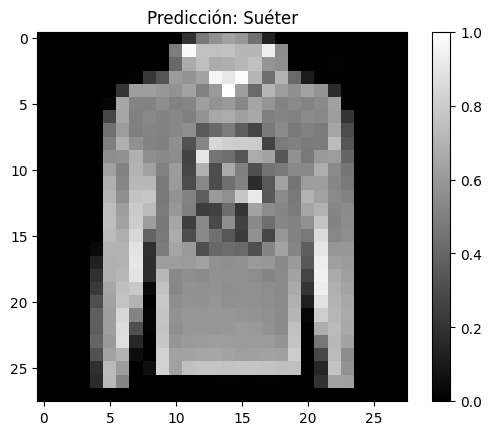

Etiqueta real: Suéter


In [3]:
# =========================
# 1. LIBRERÍAS
# =========================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 2. CARGAR DATASET
# =========================
fashion_mnist = keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# =========================
# 3. NORMALIZAR DATOS
# =========================
x_train = x_train / 255.0
x_test = x_test / 255.0

# =========================
# 4. CREAR MODELO
# =========================
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),   # Convierte imagen 28x28 en vector
    layers.Dense(128, activation='relu'),   # Capa oculta
    layers.Dense(64, activation='relu'),    # Capa oculta
    layers.Dense(10, activation='softmax')  # Salida (10 clases)
])

# =========================
# 5. COMPILAR MODELO
# =========================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# 6. ENTRENAMIENTO
# =========================
model.fit(x_train, y_train, epochs=10)

# =========================
# 7. EVALUACIÓN
# =========================
test_loss, test_acc = model.evaluate(x_test, y_test)

print("\nPrecisión en test:", test_acc)

# =========================
# 8. PREDICCIONES
# =========================
predictions = model.predict(x_test)

# Mostrar la primera predicción
print("\nPredicción:", np.argmax(predictions[0]))
print("Etiqueta real:", y_test[0])

# =========================
# 9. VISUALIZACIÓN
# =========================
class_names = [
    "Camiseta", "Pantalón", "Suéter", "Vestido", "Abrigo",
    "Sandalia", "Camisa", "Zapatilla", "Bolso", "Botín"
]

import random

i = random.randint(0, len(x_test)-1)

plt.imshow(x_test[i], cmap='gray')
plt.title(f"Predicción: {class_names[np.argmax(predictions[i])]}")
plt.colorbar()
plt.show()

print("Etiqueta real:", class_names[y_test[i]])